Unemployment Analysis With Python

Setting Working Directories

In [1]:
import os
print(os.getcwd())

C:\Users\Lenovo\OneDrive\Desktop\unemloyment


In [2]:
!pip install plotly

In [4]:
import plotly.express as px

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
## Supress warnings
import warnings
warnings.filterwarnings("ignore")

In [6]:
import os
print(os.getcwd())

C:\Users\Lenovo\OneDrive\Desktop\unemloyment


In [7]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'Nitika Yeole_2.ipynb', 'Unemployment in India.csv', 'Untitled.ipynb']


In [8]:
import os

for file in os.listdir():
    print(file)

.ipynb_checkpoints
Nitika Yeole_2.ipynb
Unemployment in India.csv
Untitled.ipynb


In [9]:
import os

print("Current folder:", os.getcwd())
print("Files:", os.listdir())
print("File exists:", os.path.exists("unemployment.csv"))

Current folder: C:\Users\Lenovo\OneDrive\Desktop\unemloyment
Files: ['.ipynb_checkpoints', 'Nitika Yeole_2.ipynb', 'Unemployment in India.csv', 'Untitled.ipynb']
File exists: False


In [10]:
import pandas as pd

data = pd.read_csv("Unemployment in India.csv")
print("Data has been successfully loaded")

Data has been successfully loaded


Checking and cleaning the dataset

In [11]:
data

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [13]:
data.shape

(768, 7)

In [14]:
data.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


* we got statistical summary of our dataset

Let’s see if this dataset contains missing values or not:

In [15]:
print(data.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


While analyzing the missing values, I found that the column names are not correct. So, for a better understanding of this data, I will rename all the columns:

In [16]:
print(data.columns)
print(len(data.columns))

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')
7


In [17]:
data.columns = [
    "States",
    "Date",
    "Frequency",
    "Estimated Unemployment Rate",
    "Estimated Employed",
    "Estimated Labour Participation Rate",
    "Area"
]

Now let’s have a look at the correlation between the features of this dataset:

Heatmap

In [20]:
import seaborn as sns

sns.set_theme(style="whitegrid")

In [21]:
import matplotlib.pyplot as plt

print(plt.style.available)

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [22]:
plt.style.use("seaborn-v0_8-whitegrid")

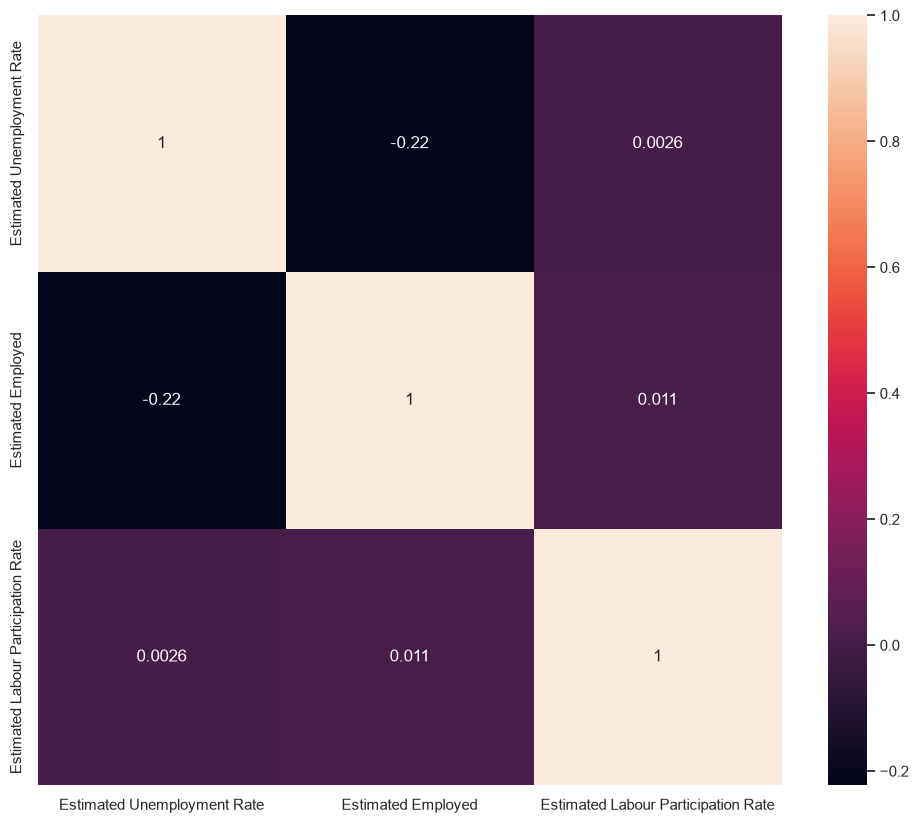

In [23]:
import seaborn as sns
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,10))
sns.heatmap(data.select_dtypes(include="number").corr(), annot=True)
plt.show()

Unemployment Rate Analysis: Data Visualization

* Now let’s visualize the data to analyze the unemployment rate. I will first take a look at the estimated number of employees according to different regions of India:

In [25]:
data.columns= ["States","Date","Frequency",
"Estimated Unemployment Rate","Estimated Employed",
"Estimated Labour Participation Rate","Region",
"longitude","latitude"]
plt.title("Indian Unemployment")
sns.histplot(x="Estimated Employed", hue="Region", data=data)
plt.show()

ValueError: Length mismatch: Expected axis has 7 elements, new values have 9 elements

In [28]:
print(len(data.columns))

7


In [29]:
print(data.columns)

Index(['States', 'Date', 'Frequency', 'Estimated Unemployment Rate',
       'Estimated Employed', 'Estimated Labour Participation Rate', 'Region'],
      dtype='str')


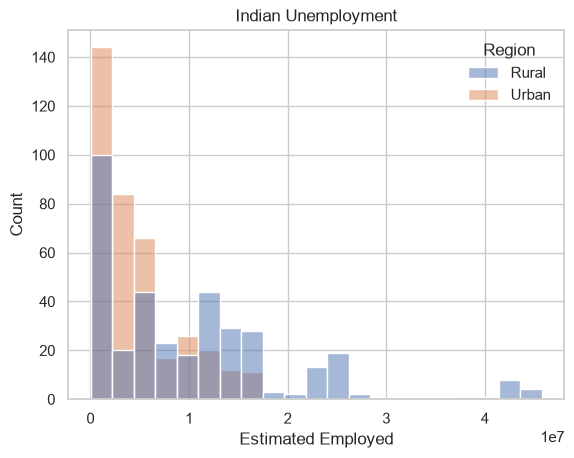

In [30]:
data.columns= ["States","Date","Frequency",
"Estimated Unemployment Rate","Estimated Employed",
"Estimated Labour Participation Rate","Region"]
plt.title("Indian Unemployment")
sns.histplot(x="Estimated Employed", hue="Region", data=data)
plt.show()

Now let’s see the unemployment rate according to different regions of India:

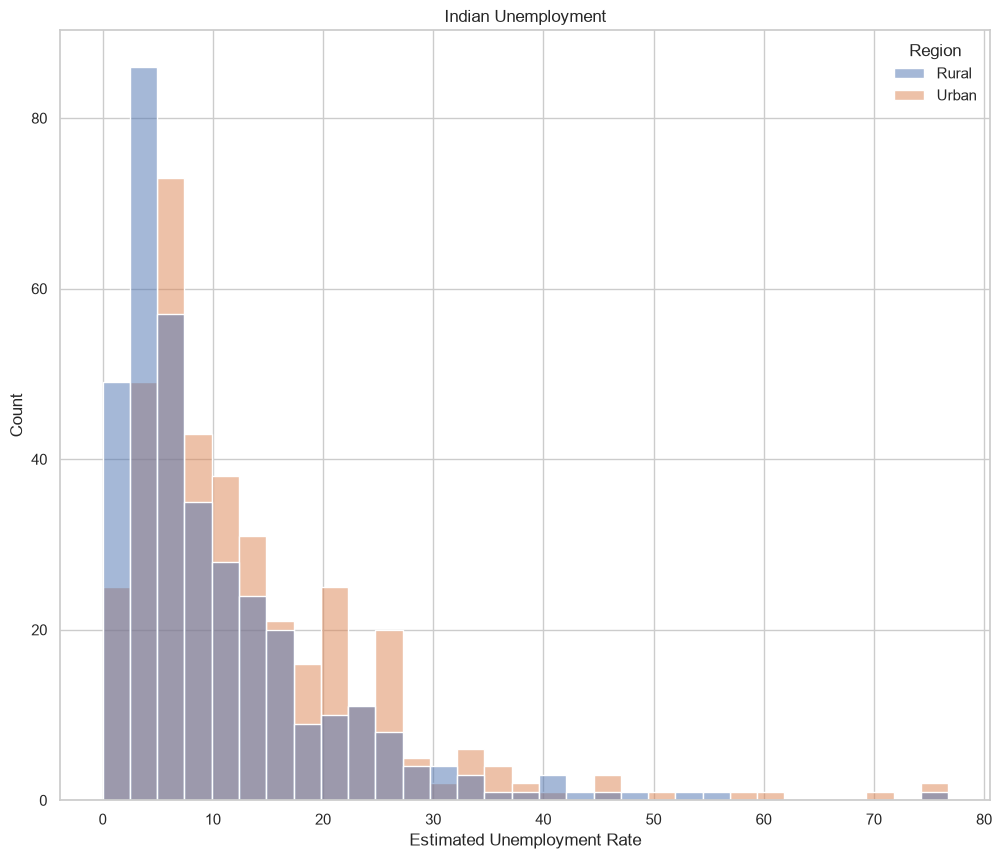

In [31]:
plt.figure(figsize=(12, 10))
plt.title("Indian Unemployment")
sns.histplot(x="Estimated Unemployment Rate", hue="Region", data=data)
plt.show()

Now let’s create a dashboard to analyze the unemployment rate of each Indian state by region. For this, I’ll use a sunburst plot:

In [32]:
unemploment = data[["States", "Region", "Estimated Unemployment Rate"]]
figure = px.sunburst(unemploment, path=["Region", "States"],
values="Estimated Unemployment Rate",
width=700, height=700, color_continuous_scale="RdY1Gn",
title="Unemployment Rate in India")
figure.show()

ValueError: ('Non-leaves rows are not permitted in the dataframe \n', ('', ''), 'is not a leaf.')

In [33]:
print(unemploment.isnull().sum())

States                         28
Region                         28
Estimated Unemployment Rate    28
dtype: int64


In [34]:
print(unemploment[unemploment["States"] == ""])
print(unemploment[unemploment["Region"] == ""])

Empty DataFrame
Columns: [States, Region, Estimated Unemployment Rate]
Index: []
Empty DataFrame
Columns: [States, Region, Estimated Unemployment Rate]
Index: []


In [35]:
unemploment = unemploment.dropna()

In [36]:
unemploment = unemploment[
    (unemploment["States"] != "") &
    (unemploment["Region"] != "")
]

In [37]:
print(unemploment.duplicated(subset=["Region","States"]).sum())

685


In [38]:
unemploment = unemploment.groupby(
    ["Region","States"],
    as_index=False
)["Estimated Unemployment Rate"].mean()

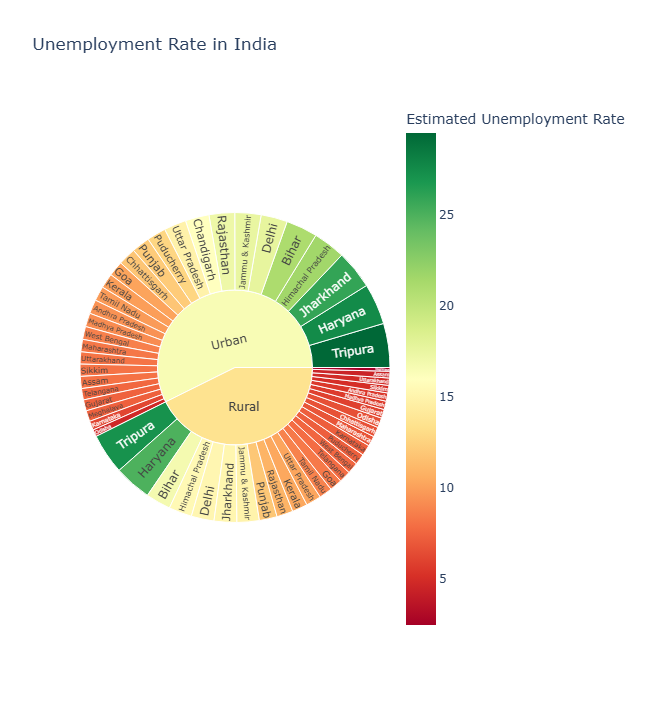

In [39]:
figure = px.sunburst(
    unemploment,
    path=["Region", "States"],
    values="Estimated Unemployment Rate",
    width=700,
    height=700,
    color="Estimated Unemployment Rate",
    color_continuous_scale="RdYlGn",
    title="Unemployment Rate in India"
)

figure.show()

Which Region has the most data

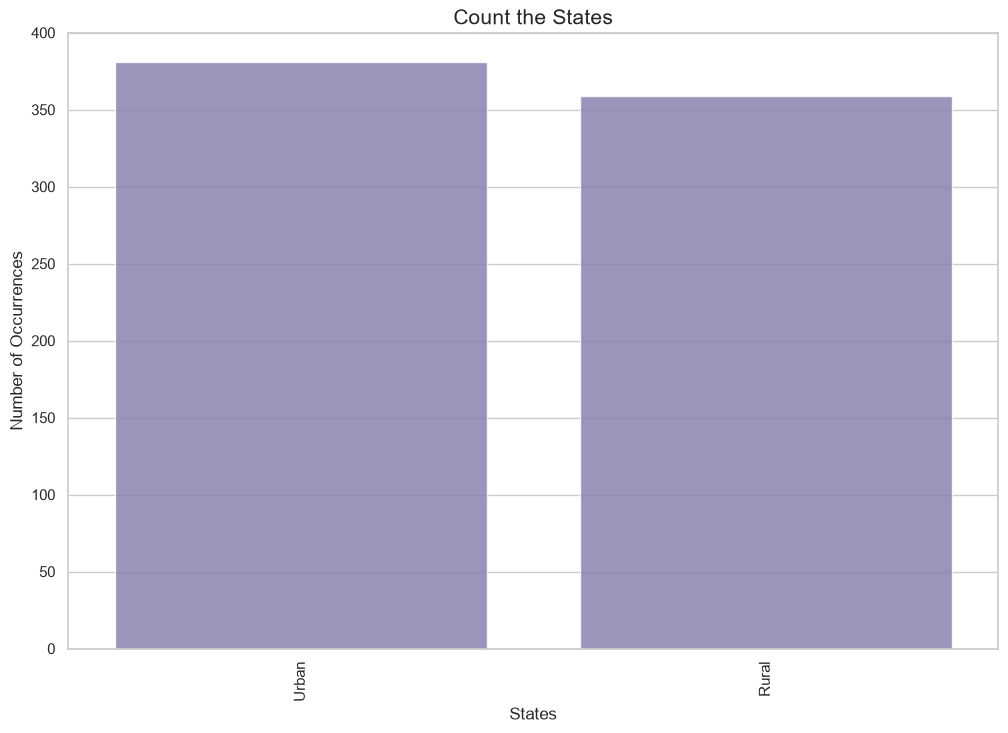

In [41]:
color = sns.color_palette()
cnt_srs = data["Region"].value_counts()

plt.figure(figsize=(12, 8))

sns.barplot(
    x=cnt_srs.index,
    y=cnt_srs.values,
    alpha=0.8,
    color=color[4]
)

plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('States', fontsize=12)
plt.title('Count the States', fontsize=15)
plt.xticks(rotation=90)
plt.show()

Take the mean of rate Region by Region

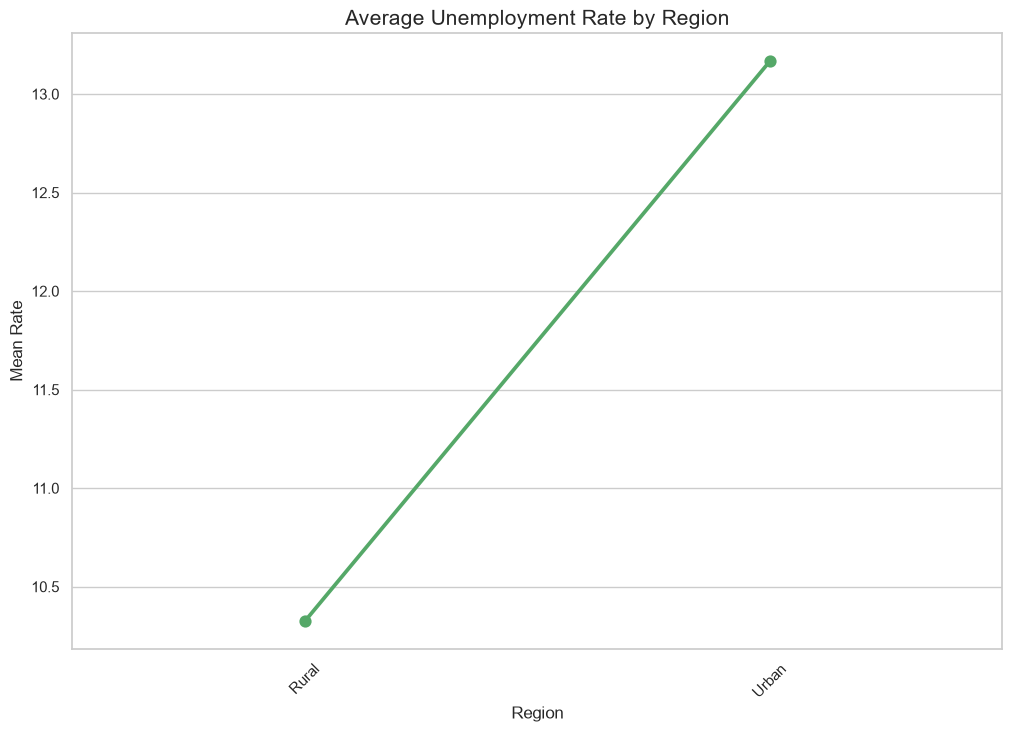

In [43]:
grouped_df = data.groupby("Region")["Estimated Unemployment Rate"].mean().reset_index()

plt.figure(figsize=(12, 8))

sns.pointplot(
    x="Region",
    y="Estimated Unemployment Rate",
    data=grouped_df,
    color=color[2]
)

plt.ylabel('Mean Rate', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.title("Average Unemployment Rate by Region", fontsize=15)
plt.xticks(rotation=45)
plt.show()

See the number of unique Region

In [44]:
data.Region.nunique()

2

See exact numbers

In [45]:
make_total = data.pivot_table("Estimated Unemployment Rate",index=['Region'],aggfunc='mean')
topstate=make_total.sort_values(by='Estimated Unemployment Rate',ascending=False)[:47]
print(topstate)

        Estimated Unemployment Rate
Region                             
Urban                     13.166614
Rural                     10.324791


In [49]:
maketotal_1 = data.pivot_table(values='Estimated Unemployment Rate',index=['Region'],aggfunc=np.std)
df1 = maketotal_1.reset_index().dropna(subset=['Estimated Unemployment Rate'])
df2 = df1.loc[df1.groupby('Region')['Estimated Unemployment Rate'].idxmax()]
for index, row in grouped_df.iterrows():
    print(row['Region'], "Region which", row['Region'], "has the highest yearly fluctuation.")

Rural Region which Rural has the highest yearly fluctuation.
Urban Region which Urban has the highest yearly fluctuation.


Conclusions:

* So this is how you can analyze the unemployment rate by using the Python programming language.
* Unemployment is measured by the unemployment rate which is the number of people who are unemployed as a percentage of the total labour force.
* East Region which East has the highest yearly fluncation.
* North Region which North has the highest yearly fluncation.
* Northeast Region which Northeast has the highest yearly fluncation.
* South Region which South has the highest yearly fluncation.
* West Region which West has the highest yearly fluncation.